# Frontier RCCL-Allreduce — Plots

Raw data = OSU text output under `results/sweep/N<nodes>_job<id>/{A,B,C,D}_*.txt`,
parsed in **cell 1** into a tidy DataFrame `data`. **Cell 2** defines the styling and
all plot functions (collapse it to hide the code). Every cell after that is a **one-line
call** — run it and tweak the argument.

Each axis shows a small italic "lower/higher is better" note beside its label. Configs:
MPICH (host CPU) / MPICH (device) / **MPICH-RCCL** / Cray MPICH.

In [10]:
# === Cell 1: load & clean the sweep data =================================
import os, re, glob
import numpy as np, pandas as pd

RESULTS = "results/sweep" if os.path.isdir("results/sweep") else "../results/sweep"

OSU_FILES = {"A":"A_mpich_host.txt","B":"B_mpich_dev.txt",
             "C":"C_mpich_rccl.txt","D":"D_cray_gpuaware.txt"}
LABEL = {"A":"MPICH (host CPU)","B":"MPICH (device)","C":"MPICH-RCCL",
         "D":"Cray MPICH","E":"RCCL (rccl-tests)"}

def parse_osu(path):
    out = []
    for line in open(path):
        p = line.split()
        if len(p) >= 2 and p[0].isdigit():
            try:
                out.append((int(p[0]), float(p[1]),
                            float(p[2]) if len(p) > 2 else np.nan,
                            float(p[3]) if len(p) > 3 else np.nan))
            except ValueError:
                pass
    return out

rows = []
for d in sorted(glob.glob(os.path.join(RESULTS, "N*_job*"))):
    m = re.match(r"N(\d+)_job(\d+)", os.path.basename(d))
    if not m:
        continue
    nodes, job = int(m.group(1)), int(m.group(2))
    for cfg, fn in OSU_FILES.items():
        fp = os.path.join(d, fn)
        if os.path.exists(fp):
            for s, a, mn, mx in parse_osu(fp):
                rows.append(dict(nodes=nodes, job=job, config=cfg, size=s, avg=a, min=mn, max=mx))

raw = pd.DataFrame(rows); raw = raw[raw["avg"] > 0]
data = (raw.groupby(["nodes","config","size"], as_index=False)
           .agg(avg=("avg","mean"), std=("avg","std"), nreps=("job","nunique")))
print("configs:", sorted(data.config.unique()), "| nodes:", sorted(data.nodes.unique()),
      "| sizes:", data["size"].nunique())
data.head()

configs: ['A', 'B', 'C', 'D'] | nodes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)] | sizes: 29


,nodes,config,size,avg,std,nreps
0,1,A,4,17.140000,0.062450,3
1,1,A,8,16.923333,0.066583,3
2,1,A,16,16.846667,0.250267,3
3,1,A,32,27.606667,0.265016,3
4,1,A,64,28.370000,0.096437,3


In [11]:
# === Cell 2: style + plot functions  (collapse this cell to hide the code) =
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams["font.family"] = "STIXGeneral"; mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams.update({"font.size":18,"axes.titlesize":22,"axes.labelsize":20,
                     "legend.fontsize":13,"xtick.labelsize":16,"ytick.labelsize":16})

SPEEDUP_COLOR = "#2ca02c"          # green reserved for the speedup line only
LAT_MAIN = "Latency (\u00b5s, log)"
SPD_MAIN = lambda base: f"{LABEL['C']} speedup vs {LABEL[base]}"
STYLE = {   # all data lines uniform: solid, circle markers, same weight (distinguished by color)
    "A": dict(color="#9e9e9e", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["A"]),
    "B": dict(color="#1f77b4", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["B"]),
    "C": dict(color="#d62728", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["C"]),
    "D": dict(color="#7e4bbd", marker="o", linestyle="-", linewidth=2, markersize=5, label=LABEL["D"]),
}
ORDER = ["A","B","C","D"]           # E (pure RCCL) parsed but not plotted

def sci(x,_):
    if x <= 0: return "0"
    e = int(np.floor(np.log10(x))); b = x/10**e
    return rf"${int(round(b))}\times10^{{{e}}}$"

def human(nb):
    nb = float(nb)
    for u in ["B","KiB","MiB","GiB"]:
        if nb < 1024: return f"{int(nb)} {u}"
        nb /= 1024
    return f"{int(nb)} TiB"

def parse_size(x):
    # accept "1MiB", "512KiB", "1GiB", "8B", "1kb", ... or a raw byte count
    if isinstance(x, (int, float)): return int(x)
    s = str(x).strip().lower().replace(" ", "")
    for suf, m in [("gib",1024**3),("gb",1024**3),("mib",1024**2),("mb",1024**2),
                   ("kib",1024),("kb",1024),("b",1),("g",1024**3),("m",1024**2),("k",1024)]:
        if s.endswith(suf):
            return int(float(s[:-len(suf)]) * m)
    return int(float(s))

def series(nodes, config):
    d = data[(data.nodes==nodes)&(data.config==config)].sort_values("size")
    return d["size"].values, d["avg"].values

def ylabel2(ax, main, sub, side="left"):
    # main axis label + a small italic light-gray "sub" line just outboard of it
    if side == "left":
        lbl = ax.set_ylabel(main); rot, dx = 90, -20
    else:
        lbl = ax.set_ylabel(main, rotation=270, labelpad=42); rot, dx = 270, 20
    ax.annotate(sub, xy=(0.5,0.5), xycoords=lbl, textcoords="offset points",
                xytext=(dx,0), rotation=rot, ha="center", va="center",
                fontsize=12.5, style="italic", color="#444444")

def finish(fig):
    fig.patch.set_facecolor("white"); fig.tight_layout(); plt.show()

def plot_latency_vs_size(nodes, speedup_over="D"):
    fig, ax1 = plt.subplots(figsize=(16,10))
    for cfg in ORDER:
        x,y = series(nodes,cfg)
        if len(x): ax1.plot(x,y,**STYLE[cfg])
    ax1.set_xscale("log", base=2); ax1.set_yscale("log")
    ax1.set_xlabel("Message size (bytes, log2)")
    ylabel2(ax1, LAT_MAIN, "lower is better", "left")
    ax1.set_title(f"Allreduce latency \u2014 {nodes} node(s)")
    ax1.yaxis.set_major_formatter(FuncFormatter(sci)); ax1.grid(True, which="both", ls="--", alpha=0.4)
    xc,yc = series(nodes,"C"); xb,yb = series(nodes,speedup_over)
    if len(xc) and len(xb):
        common = np.intersect1d(xc,xb)
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax2 = ax1.twinx()
        ax2.plot(common, sc, marker="o", linestyle="--", color=SPEEDUP_COLOR, lw=2, label=f"{LABEL['C']} speedup vs {LABEL[speedup_over]}")
        ax2.axhline(1, color="#aaaaaa", ls="--", lw=1); ax2.set_yscale("log", base=2)
        ylabel2(ax2, SPD_MAIN(speedup_over), "higher is better", "right")
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
        i = int(np.argmax(sc))
        ax2.annotate(f"{sc[i]:.1f}\u00d7", xy=(common[i],sc[i]), xytext=(common[i], sc[i]*0.6),
                     fontsize=15, bbox=dict(fc="white",ec="black",boxstyle="round,pad=0.3"),
                     arrowprops=dict(arrowstyle="->"))
        h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc="upper left", framealpha=1)
    else:
        ax1.legend(loc="upper left", framealpha=1)
    finish(fig)

def plot_speedup_vs_size(baseline="D"):
    fig, ax = plt.subplots(figsize=(16,10))
    for n in sorted(data.nodes.unique()):
        xc,yc = series(n,"C"); xb,yb = series(n,baseline)
        common = np.intersect1d(xc,xb)
        if not len(common): continue
        sc = np.array([yb[list(xb).index(s)]/yc[list(xc).index(s)] for s in common])
        ax.plot(common, sc, marker="o", linestyle="-", lw=2, label=f"{n} nodes")
    ax.axhline(1, color="#aaaaaa", ls="--", lw=1.5)
    ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: (f"{y:g}" if y>=1 else "")))
    ax.set_xlabel("Message size (bytes, log2)")
    ylabel2(ax, SPD_MAIN(baseline), "higher is better", "left")
    ax.set_title(f"{LABEL['C']} speedup over {LABEL[baseline]} (per node count)")
    ax.grid(True, which="both", ls="--", alpha=0.4); ax.legend(title="scale", framealpha=1, ncol=2)
    finish(fig)

def plot_scaling(size):
    size = parse_size(size)
    fig, ax = plt.subplots(figsize=(16,10))
    for cfg in ORDER:
        d = data[(data.config==cfg)&(data["size"]==size)].sort_values("nodes")
        if len(d): ax.plot(d.nodes, d.avg, **STYLE[cfg])
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(sorted(data.nodes.unique()))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{int(x)}"))
    ax.set_xlabel("Nodes")
    ylabel2(ax, LAT_MAIN, "lower is better", "left")
    ax.set_title(f"Allreduce scaling @ {human(size)}")
    ax.yaxis.set_major_formatter(FuncFormatter(sci)); ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(framealpha=1)
    finish(fig)

def plot_crossover(baseline="D", annotate=True, vmax=None):
    # linear diverging color centered at 1x (= equal); extremes saturate red/blue.
    # cell text = linear speedup (>1 = MPICH-RCCL faster). vmax caps the red end.
    pc = data[data.config=="C"].pivot_table(index="size", columns="nodes", values="avg")
    pb = data[data.config==baseline].pivot_table(index="size", columns="nodes", values="avg")
    cols = sorted(set(pc.columns)&set(pb.columns)); idx = sorted(set(pc.index)&set(pb.index))
    lin = (pb.loc[idx,cols] / pc.loc[idx,cols])          # linear speedup: MPICH-RCCL / baseline (1 = equal)
    lo = min(np.nanmin(lin.values), 0.99)
    hi = vmax if vmax is not None else max(np.nanmax(lin.values), 1.01)
    norm = TwoSlopeNorm(vmin=lo, vcenter=1.0, vmax=hi)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(lin.values, cmap="RdBu_r", norm=norm, origin="lower", aspect="auto")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
    ax.set_yticks(range(len(idx)));  ax.set_yticklabels([human(s) for s in idx], fontsize=9)
    ax.set_xlabel("Nodes"); ax.set_ylabel("Message size")
    if annotate:
        for i in range(len(idx)):
            for j in range(len(cols)):
                v = lin.values[i,j]
                if np.isnan(v): continue
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9,
                        color="white" if (v > 2.5 or v < 0.5) else "black")
    ax.set_title(f"{LABEL['C']} vs {LABEL[baseline]}")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(f"speedup: {LABEL['C']} / {LABEL[baseline]}", rotation=270, labelpad=22)
    # same styled note as the axis labels, beside the colorbar label (clip off so the narrow bar doesn't hide it)
    cb.ax.annotate(f"1 = equal;  red = {LABEL['C']} faster", xy=(0.5,0.5),
                   xycoords=cb.ax.yaxis.label, textcoords="offset points", xytext=(20,0),
                   rotation=270, ha="center", va="center", fontsize=12.5,
                   style="italic", color="#444444", annotation_clip=False)
    finish(fig)

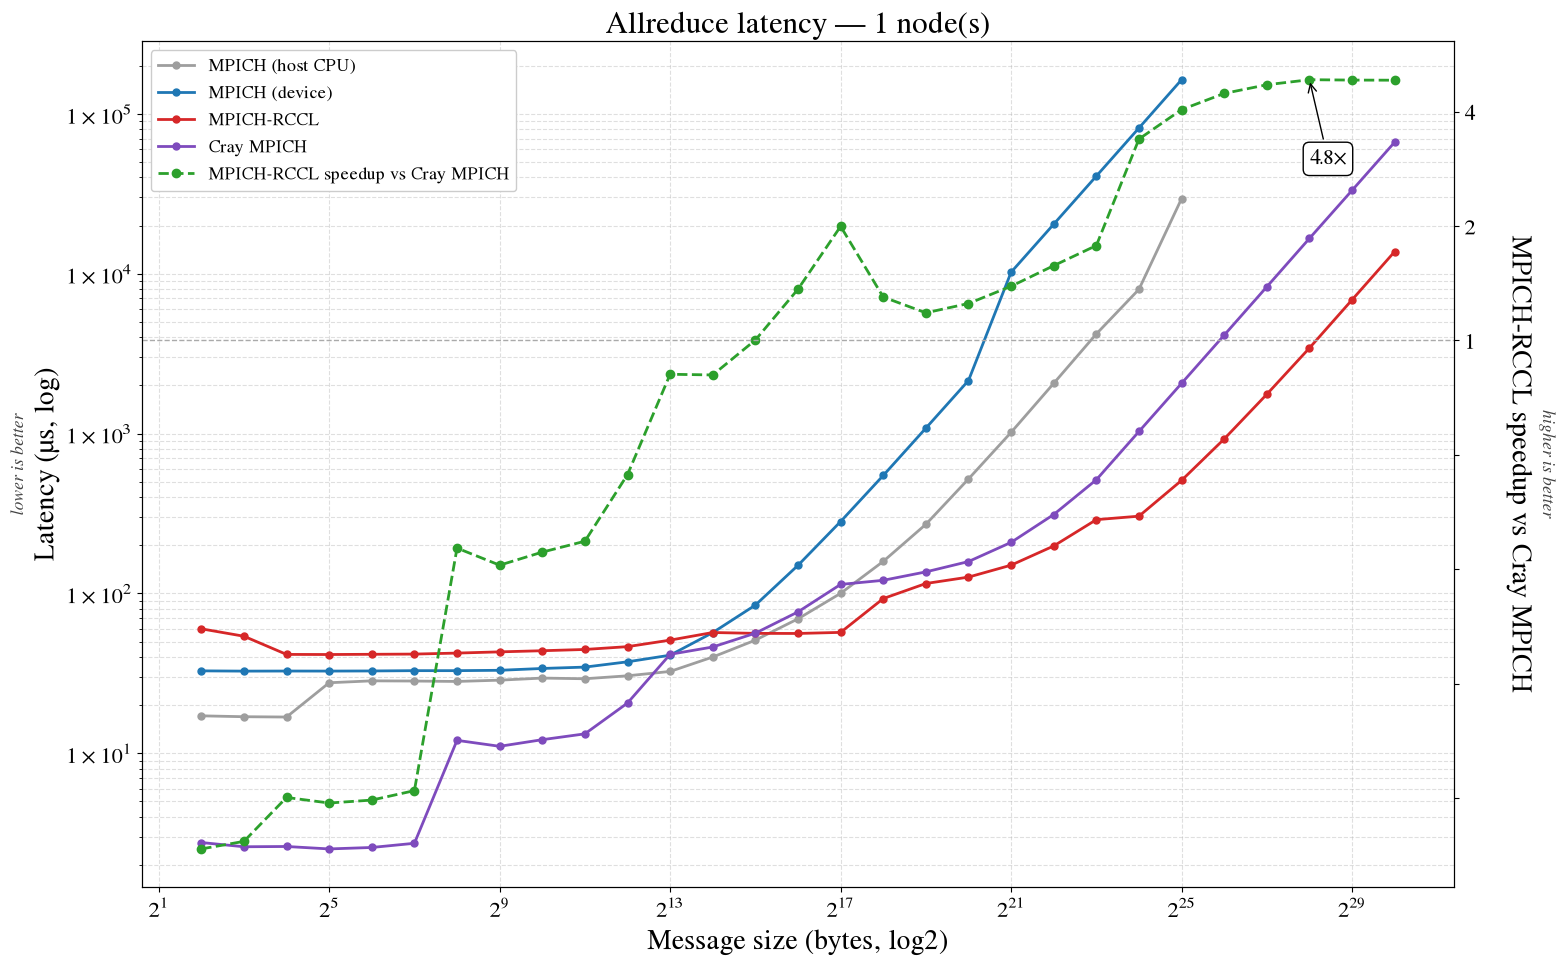

In [12]:
plot_latency_vs_size(1)          # node count: 1, 2, 4, 8, 16, 32, 64, ...

In [ ]:
plot_speedup_vs_size("D")        # baseline: "D"=Cray, "B"=MPICH (device)

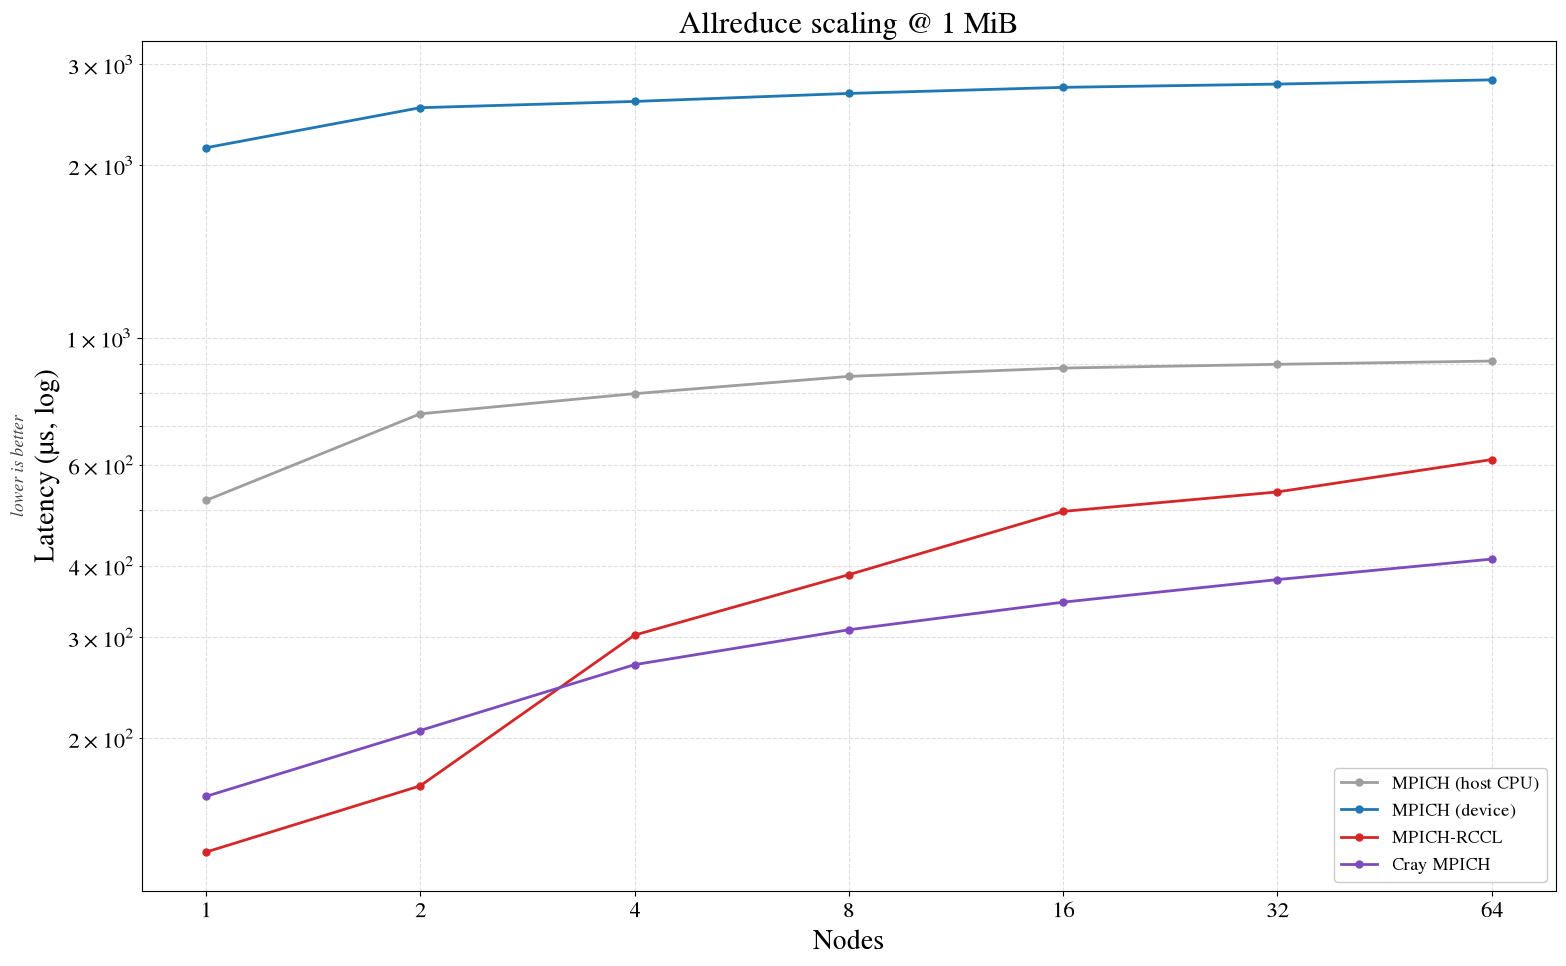

In [13]:
plot_scaling("1MiB")             # size: "1KiB", "512KiB", "16MiB", "1GiB", ... (raw bytes also ok)

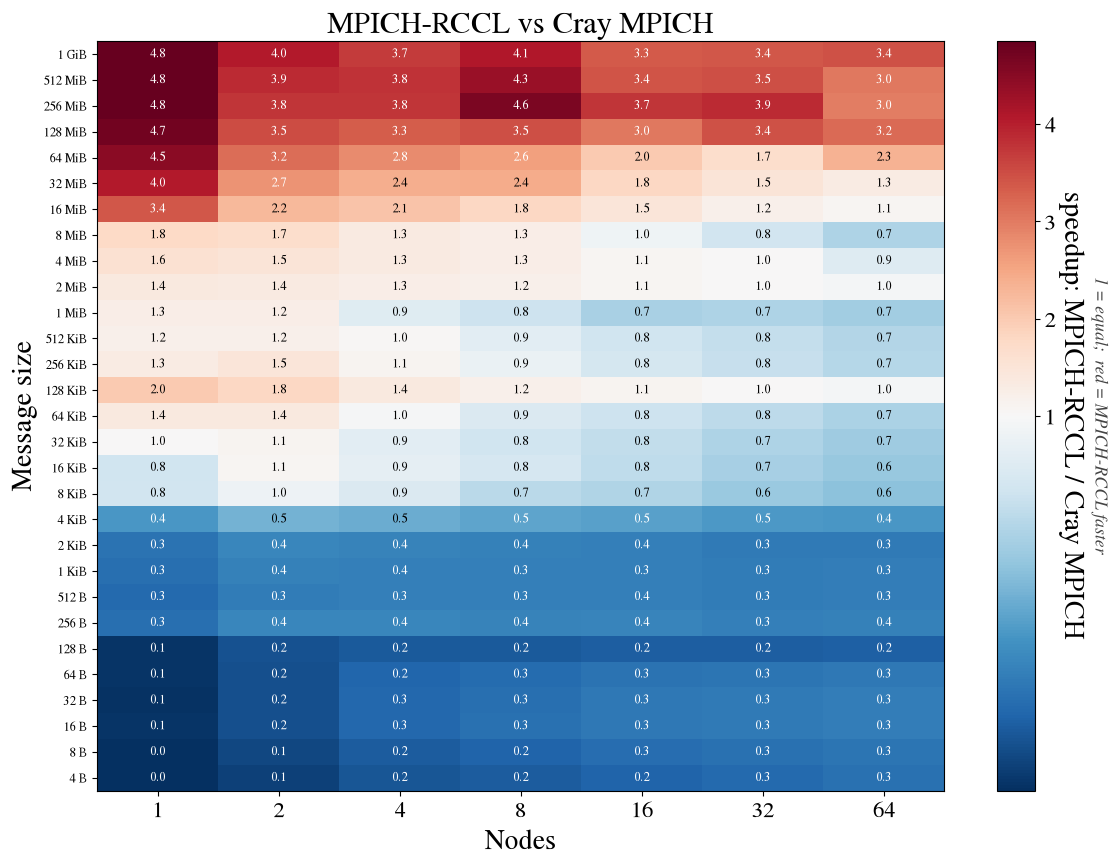

In [14]:
plot_crossover("D")              # crossover heatmap: red = MPICH-RCCL faster